# Modelling

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#linear regression models
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.svm import SVR
from prophet import Prophet
#k-nearest neighbors regressor
from sklearn.neighbors import KNeighborsRegressor
#random forest regressor
from sklearn.ensemble import RandomForestRegressor
# evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error, mean_absolute_error
#gradient boosting regressor
from sklearn.ensemble import GradientBoostingRegressor
# pipelines
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
#scaling
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler

Importing plotly failed. Interactive plots will not work.


# Lag_1 GDP Growth Model

### Model Performance on unprocessed data

In [3]:
unprocessed_data = pd.read_csv("cleaned_gdp_growth_lag1.csv")
unprocessed_data.head()

,year,gdp_growth(%),gdp_growth_lag1(%),gdp_growth_lag2(%),household_consumption(%)_lag1,unemployment_rate(%)_lag1,under_earning_percentage(%)_lag1,inflation_rate(%)_lag1,lending_interest_rate(%)_lag1,fdi_net_flows(US$)_lag1,tax_revenue_percentage(%)_lag1,state_revenues_percentage(%)_lag1,gross_capital_formation_growth(%)_lag1,import_of_goods_and_services(US$)_lag1,export_of_goods_and_services(US$)_lag1,exchange_rate(IDR/US$)_lag1
0,1981,7.927157,9.880078,6.165775,70.834204,5.620902,89.164321,18.035422,21.504167,180000000.0,21.779838,22.897656,24.369558,1.607649e+10,2.208839e+10,626.994000
1,1982,2.246445,7.927157,9.880078,76.531919,5.620827,88.921829,12.265908,21.504167,133000000.0,21.946434,25.474300,12.398103,2.184722e+10,2.362907e+10,631.756667
2,1983,4.192967,2.246445,7.927157,81.334706,5.504006,75.150527,9.445425,21.504167,225000000.0,20.056144,21.489923,5.647824,2.370914e+10,2.017659e+10,661.420750
3,1984,6.975528,4.192967,2.246445,71.666649,5.565429,67.419547,11.799738,21.504167,292000000.0,18.822865,21.046818,627.499564,2.335427e+10,2.248829e+10,909.264833
4,1985,2.462144,6.975528,4.192967,72.352702,5.744096,86.200000,10.455039,21.504167,222000000.0,17.484389,21.508291,52.568955,1.934295e+10,2.317777e+10,1025.944833


In [4]:
# spilt x and y
y = unprocessed_data["gdp_growth_lag1(%)"]
x = unprocessed_data.drop(columns=["gdp_growth_lag1(%)", "gdp_growth(%)"], axis=1)

In [5]:
print(f"target: {y.name}")
print(f"feature: {x.columns}, n_features:{x.shape[1]}")

target: gdp_growth_lag1(%)
feature: Index(['year', 'gdp_growth_lag2(%)', 'household_consumption(%)_lag1',
       'unemployment_rate(%)_lag1', 'under_earning_percentage(%)_lag1',
       'inflation_rate(%)_lag1', 'lending_interest_rate(%)_lag1',
       'fdi_net_flows(US$)_lag1', 'tax_revenue_percentage(%)_lag1',
       'state_revenues_percentage(%)_lag1',
       'gross_capital_formation_growth(%)_lag1',
       'import_of_goods_and_services(US$)_lag1',
       'export_of_goods_and_services(US$)_lag1',
       'exchange_rate(IDR/US$)_lag1'],
      dtype='object'), n_features:14


In [6]:
#Split data train test

def time_series_split(x, y, test_split):
    """
    return (x_train, y_train, x_test, y_test)
    """

    if not 0 < test_split < 1:
        raise ValueError("test_split must be between 0 and 1")

    if len(x) != len(y):
        raise ValueError("x and y must have the same length")

    train_len = int(len(x) * (1 - test_split))

    x_train = x.iloc[:train_len]
    y_train = y.iloc[:train_len]

    x_test = x.iloc[train_len:]
    y_test = y.iloc[train_len:]

    return x_train, y_train, x_test, y_test

In [7]:
x_train, y_train, x_test, y_test = time_series_split(x,y,test_split=0.20)

In [8]:
# Models
models = {"LinearRegression": LinearRegression(),
            "Lasso" : Lasso(),
            "Ridge" : Ridge()}

performances = {"Model" : [],
                "MAE" : [],
                "MSE" : [],
                "RMSE" : [],
                "R2" : []}

for name, model in models.items():
    # train the model
    model.fit(x_train, y_train)
    # test the model
    y_pred = model.predict(x_test)
    # evaluate the model
    performances["Model"].append(name)
    performances["MAE"].append(mean_absolute_error(y_test, y_pred))
    performances["MSE"].append(mean_squared_error(y_test, y_pred))
    performances["RMSE"].append(root_mean_squared_error(y_test, y_pred))
    performances["R2"].append(r2_score(y_test, y_pred))

performances_df = pd.DataFrame(performances)


/opt/miniconda3/envs/dlenv/lib/python3.10/site-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 6.742e+01, tolerance: 4.518e-02
  model = cd_fast.enet_coordinate_descent(
/opt/miniconda3/envs/dlenv/lib/python3.10/site-packages/sklearn/linear_model/_ridge.py:213: LinAlgWarning: Ill-conditioned matrix (rcond=2.79388e-23): result may not be accurate.
  return linalg.solve(A, Xy, assume_a="pos", overwrite_a=True).T


              Model       MAE        MSE      RMSE        R2
0  LinearRegression  3.932051  29.705218  5.450249 -4.959850
1             Lasso  2.306259  11.646059  3.412632 -1.336585
2             Ridge  3.782396  27.733918  5.266300 -4.564342


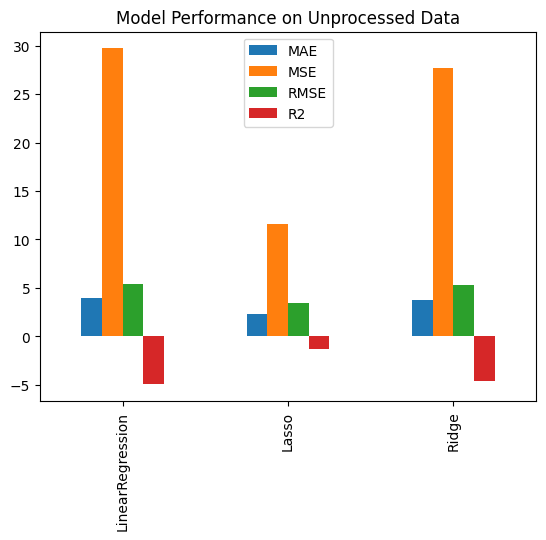

In [9]:
print(performances_df)
performances_df.plot(kind="bar")
plt.title("Model Performance on Unprocessed Data")
plt.xticks([0,1,2], performances_df["Model"]);
plt.show()

### Model Performance on Processed Data

In [10]:
processed_data = pd.read_csv("feature_engineered_gdp_growth_lag1.csv")
processed_data.head()

,real_interest_rate,lending_interest_rate(%)_lag1,inflation_rate(%)_lag1,exchange_rate_change_lag1,export_import_ratio,gross_capital_formation_growth(%)_lag1,fdi_net_flows(US$)_lag1,state_revenues_percentage(%)_lag1,gdp_growth_lag2(%),gdp_growth_lag1(%),gdp_growth(%)
0,3.468745,21.504167,2.946302,0.007567,1.373956,24.369558,19.008467,3.173780,6.165775,9.880078,7.927157
1,9.238259,21.504167,2.585197,0.007567,1.081559,12.398103,18.705860,3.276174,9.880078,7.927157,2.246445
2,12.058741,21.504167,2.346164,0.045886,0.851005,5.647824,19.231611,3.113067,7.927157,2.246445,4.192967
3,9.704428,21.504167,2.549425,0.318246,0.962920,627.499564,19.492264,3.093168,2.246445,4.192967,6.975528
4,11.049127,21.504167,2.438430,0.120733,1.198254,52.568955,19.218188,3.113884,4.192967,6.975528,2.462144


In [11]:
# spilt x and y
y = processed_data["gdp_growth_lag1(%)"]
x = processed_data.drop(columns=["gdp_growth_lag1(%)", "gdp_growth(%)",
                                "lending_interest_rate(%)_lag1",
                                "inflation_rate(%)_lag1",
                                "fdi_net_flows(US$)_lag1"], axis=1)
print(f"target: {y.name}")
print(f"feature: {x.columns}, n_features:{x.shape[1]}")

target: gdp_growth_lag1(%)
feature: Index(['real_interest_rate', 'exchange_rate_change_lag1',
       'export_import_ratio', 'gross_capital_formation_growth(%)_lag1',
       'state_revenues_percentage(%)_lag1', 'gdp_growth_lag2(%)'],
      dtype='object'), n_features:6


In [12]:
x_train, y_train, x_test, y_test = time_series_split(x,y,test_split=0.25)

In [13]:
# Models
np.random.seed(42)
models = {"LinearRegression": LinearRegression(),
            "Lasso" : Lasso(),
            "Ridge" : Ridge()}

performances = {"Model" : [],
                "MAE" : [],
                "MSE" : [],
                "RMSE" : [],
                "R2" : []}

for name, model in models.items():
    # train the model
    pipeline = Pipeline(steps=[('scalling', MinMaxScaler()),
                               ('model', model)])
    pipeline.fit(x_train, y_train)
    # test the model
    y_pred = pipeline.predict(x_test)
    # evaluate the model
    performances["Model"].append(name)
    performances["MAE"].append(mean_absolute_error(y_test, y_pred))
    performances["MSE"].append(mean_squared_error(y_test, y_pred))
    performances["RMSE"].append(root_mean_squared_error(y_test, y_pred))
    performances["R2"].append(r2_score(y_test, y_pred))

performances_df = pd.DataFrame(performances)

              Model       MAE       MSE      RMSE        R2
0  LinearRegression  1.482039  5.387073  2.321007 -0.196482
1             Lasso  0.984168  4.999286  2.235908 -0.110354
2             Ridge  1.248190  4.699892  2.167923 -0.043857


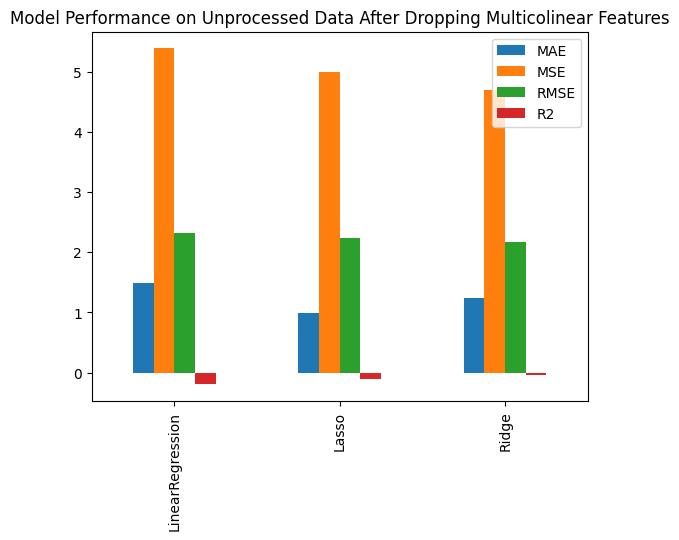

'\nMIN MAX\n              Model       MAE       MSE      RMSE        R2\n0  LinearRegression  1.482039  5.387073  2.321007 -0.196482\n1             Lasso  0.984168  4.999286  2.235908 -0.110354\n2             Ridge  1.248190  4.699892  2.167923 -0.043857\n'

In [14]:

print(performances_df)
performances_df.plot(kind="bar")
plt.title("Model Performance on Unprocessed Data After Dropping Multicolinear Features")
plt.xticks([0,1,2], performances_df["Model"]);
plt.show()

"""
UNPROCESSED DATA
              Model       MAE        MSE      RMSE        R2
0  LinearRegression  3.932051  29.705218  5.450249 -4.959850
1             Lasso  2.306259  11.646059  3.412632 -1.336585
2             Ridge  3.782396  27.733918  5.266300 -4.564342
"""
"""
WITH MULTICOLINEARITY
              Model       MAE        MSE      RMSE        R2
0  LinearRegression  1.597421   4.618318  2.149027  0.073413
1             Lasso  2.483210  12.243756  3.499108 -1.456503
2             Ridge  1.106736   5.159747  2.271508 -0.035216
"""

"""
NO MULTICOLINEARITYLY
              Model       MAE       MSE      RMSE        R2
0  LinearRegression  1.395748  6.165419  2.483026 -0.236987
1             Lasso  1.298954  5.664132  2.379944 -0.136412
2             Ridge  1.284585  5.952343  2.439742 -0.194237
"""
"""
STANDARD SCALLED
              Model       MAE       MSE      RMSE        R2
0  LinearRegression  1.482039  5.387073  2.321007 -0.196482
1             Lasso  1.204481  5.396884  2.323120 -0.198661
2             Ridge  1.473179  5.341652  2.311201 -0.186394

"""
"""
MIN MAX
              Model       MAE       MSE      RMSE        R2
0  LinearRegression  1.482039  5.387073  2.321007 -0.196482
1             Lasso  0.984168  4.999286  2.235908 -0.110354
2             Ridge  1.248190  4.699892  2.167923 -0.043857
"""


Lasso with Min-max scalling win

# GDP Growth Model

In [15]:
# spilt x and y
y = processed_data["gdp_growth(%)"]
x = processed_data.drop(columns=["gdp_growth_lag1(%)", "gdp_growth(%)",
                                "lending_interest_rate(%)_lag1",
                                "inflation_rate(%)_lag1",
                                "fdi_net_flows(US$)_lag1"], axis=1)
print(f"target: {y.name}")
print(f"feature: {x.columns}, n_features:{x.shape[1]}")

target: gdp_growth(%)
feature: Index(['real_interest_rate', 'exchange_rate_change_lag1',
       'export_import_ratio', 'gross_capital_formation_growth(%)_lag1',
       'state_revenues_percentage(%)_lag1', 'gdp_growth_lag2(%)'],
      dtype='object'), n_features:6


In [16]:
x_train, y_train, x_test, y_test = time_series_split(x,y,test_split=0.25)

In [17]:
# Models
np.random.seed(42)
models = {"LinearRegression": LinearRegression(),
            "Lasso" : Lasso(),
            "Ridge" : Ridge()}

performances = {"Model" : [],
                "MAE" : [],
                "MSE" : [],
                "RMSE" : [],
                "R2" : []}

for name, model in models.items():
    # train the model
    pipeline = Pipeline(steps=[('scalling', StandardScaler()),
                               ('model', model)])
    pipeline.fit(x_train, y_train)
    # test the model
    y_pred = pipeline.predict(x_test)
    # evaluate the model
    performances["Model"].append(name)
    performances["MAE"].append(mean_absolute_error(y_test, y_pred))
    performances["MSE"].append(mean_squared_error(y_test, y_pred))
    performances["RMSE"].append(root_mean_squared_error(y_test, y_pred))
    performances["R2"].append(r2_score(y_test, y_pred))

performances_df = pd.DataFrame(performances)

              Model       MAE       MSE      RMSE        R2
0  LinearRegression  1.225102  6.274924  2.504980 -0.460554
1             Lasso  0.869009  4.804019  2.191807 -0.118185
2             Ridge  1.173711  6.056281  2.460951 -0.409662


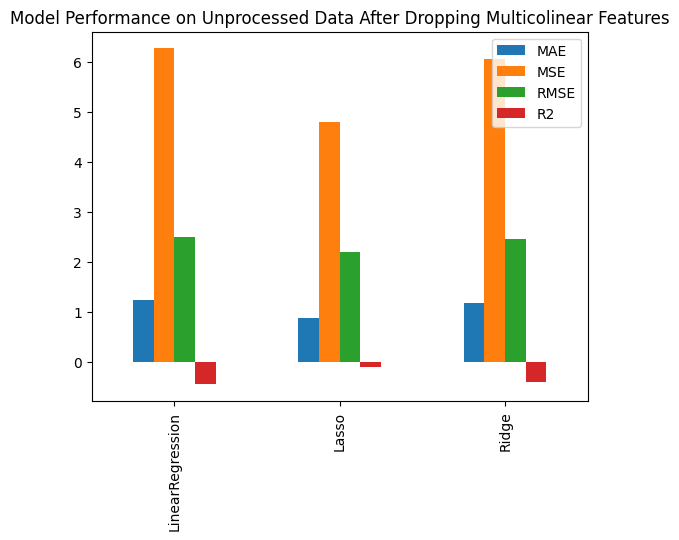

'\nSTANDARD SCALLING\n              Model       MAE       MSE      RMSE        R2\n0  LinearRegression  1.311936  6.181146  2.486191 -0.438726\n1             Lasso  0.869009  4.804019  2.191807 -0.118185\n2             Ridge  1.217080  5.930288  2.435218 -0.380336\n'

In [18]:

print(performances_df)
performances_df.plot(kind="bar")
plt.title("Model Performance on Unprocessed Data After Dropping Multicolinear Features")
plt.xticks([0,1,2], performances_df["Model"]);
plt.show()

"""
MIN MAX SCALLING

              Model       MAE       MSE      RMSE        R2
0  LinearRegression  1.311936  6.181146  2.486191 -0.438726
1             Lasso  0.877359  4.750207  2.179497 -0.105660
2             Ridge  0.839860  4.738393  2.176785 -0.102910
"""

"""
STANDARD SCALLING
              Model       MAE       MSE      RMSE        R2
0  LinearRegression  1.311936  6.181146  2.486191 -0.438726
1             Lasso  0.869009  4.804019  2.191807 -0.118185
2             Ridge  1.217080  5.930288  2.435218 -0.380336
"""

Ridge Model with Min-max Scalling wins

# Creating Pipelines For The Best Performing Model


### GDP Grwoth Lag_1 Lasso

1. Input Raw Dat :['gdp_growth_lag2(%)','inflation_rate(%)_lag1',
       'lending_interest_rate(%)_lag1','state_revenues_percentage(%)_lag1',
       'gross_capital_formation_growth(%)_lag1',
       'import_of_goods_and_services(US$)_lag1',
       'export_of_goods_and_services(US$)_lag1', 'exchange_rate(IDR/US$)_lag1']
2. Log Transform
3. Feature Enginering : ['real_interest_rate', 'exchange_rate_change_lag1',
       'export_import_ratio', 'gross_capital_formation_growth(%)_lag1',
       'state_revenues_percentage(%)_lag1', 'gdp_growth_lag1(%)'],
4. Scalling
5. Model
6. Raw Output

In [19]:
raw_df = pd.read_csv("cleaned_gdp_growth_lag1.csv")


In [20]:
raw_df.columns

Index(['year', 'gdp_growth(%)', 'gdp_growth_lag1(%)', 'gdp_growth_lag2(%)',
       'household_consumption(%)_lag1', 'unemployment_rate(%)_lag1',
       'under_earning_percentage(%)_lag1', 'inflation_rate(%)_lag1',
       'lending_interest_rate(%)_lag1', 'fdi_net_flows(US$)_lag1',
       'tax_revenue_percentage(%)_lag1', 'state_revenues_percentage(%)_lag1',
       'gross_capital_formation_growth(%)_lag1',
       'import_of_goods_and_services(US$)_lag1',
       'export_of_goods_and_services(US$)_lag1',
       'exchange_rate(IDR/US$)_lag1'],
      dtype='object')

In [21]:
# Select ONLY Inputed Data

raw_df = raw_df.drop(columns=["year",
                             'state_revenues_percentage(%)_lag1',
                             'lending_interest_rate(%)_lag1',
                              'inflation_rate(%)_lag1',
                              "unemployment_rate(%)_lag1",
                              "under_earning_percentage(%)_lag1",
                              #"fdi_net_flows(US$)_lag1",
                              "tax_revenue_percentage(%)_lag1",
                              #"exchange_rate(IDR/US$)_lag1",
                              #'gross_capital_formation_growth(%)_lag1',
                              #'state_revenues_percentage(%)_lag1'
                              ], axis = 1)

In [22]:
print(raw_df.columns, raw_df.shape)

Index(['gdp_growth(%)', 'gdp_growth_lag1(%)', 'gdp_growth_lag2(%)',
       'household_consumption(%)_lag1', 'fdi_net_flows(US$)_lag1',
       'gross_capital_formation_growth(%)_lag1',
       'import_of_goods_and_services(US$)_lag1',
       'export_of_goods_and_services(US$)_lag1',
       'exchange_rate(IDR/US$)_lag1'],
      dtype='object') (43, 9)


In [23]:
# spilt x and y
y = raw_df["gdp_growth(%)"]
x = raw_df.drop(columns=["gdp_growth(%)"], axis=1)

print(f"X:{x.columns}, SIZE: {x.shape[1]} ")
print(f"Y:{y.name}")

X:Index(['gdp_growth_lag1(%)', 'gdp_growth_lag2(%)',
       'household_consumption(%)_lag1', 'fdi_net_flows(US$)_lag1',
       'gross_capital_formation_growth(%)_lag1',
       'import_of_goods_and_services(US$)_lag1',
       'export_of_goods_and_services(US$)_lag1',
       'exchange_rate(IDR/US$)_lag1'],
      dtype='object'), SIZE: 8 
Y:gdp_growth(%)


In [24]:
from sklearn.preprocessing import FunctionTransformer

# -- Pipeline --

# 1) feature engineering pipeline
    
def add_export_import_ratio(x):
    x = x.copy()
    x['export_import_ratio'] = (x['export_of_goods_and_services(US$)_lag1'] 
                                / x['import_of_goods_and_services(US$)_lag1'])
    
    return x.drop(columns=['export_of_goods_and_services(US$)_lag1', 
                        'import_of_goods_and_services(US$)_lag1'], axis=1)

feature_engineering_pipeline = Pipeline([('export_import_ratio_adder', FunctionTransformer(add_export_import_ratio))] )  


# 2) esamble the entire preprocessing pipeline

preprocessing_pipeline = Pipeline([
    ('feature_engineering_pipeline', feature_engineering_pipeline), #  feature engineering pipeline
    ('imputer', SimpleImputer(strategy='mean')), # imputer to handle missing value (just in case for production)
    ('scaller', RobustScaler()) # scalling
     ])

# 3 Esamble all the pipelines
full_pipeline_lag1_lasso = Pipeline(steps=[
    ('preprocessing_pipeline', preprocessing_pipeline),
    ('model', Ridge(random_state=42, alpha=50))
 ])


In [25]:
x_train, y_train, x_test, y_test = time_series_split(x,y,test_split=0.25)

In [26]:
full_pipeline_lag1_lasso.fit(x_train,y_train)

,steps,"[('preprocessing_pipeline', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('feature_engineering_pipeline', ...), ('imputer', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,steps,"[('export_import_ratio_adder', ...)]"
,transform_input,None
,memory,None


In [27]:
y_pred = full_pipeline_lag1_lasso.predict(x_test)

evaluation_metrics = {'MAE': mean_absolute_error(y_test, y_pred),
                      'MSE': mean_squared_error(y_test, y_pred),
                      'RMSE': root_mean_squared_error(y_test, y_pred),
                      'R2': r2_score(y_test, y_pred)}

print(evaluation_metrics)

evaluation_metrics_df = pd.DataFrame(evaluation_metrics, index = [1])
evaluation_metrics_df


{'MAE': 0.7727257434052096, 'MSE': 4.530880409316354, 'RMSE': 2.1285864815215647, 'R2': -0.05460953078691766}


,MAE,MSE,RMSE,R2
1,0.772726,4.53088,2.128586,-0.05461


        Actual  Prediction
Year                      
2013  5.557264    5.089656
2014  5.006668    4.994785
2015  4.876322    4.945514
2016  5.033069    4.948548
2017  5.069786    4.865576
2018  5.174292    5.034032
2019  5.019288    4.926095
2020 -2.065512    4.967312
2021  3.702886    3.771073
2022  5.307197    5.242668
2023  5.049023    5.312600


<Axes: title={'center': 'How Well The Model Fits'}, xlabel='Year'>

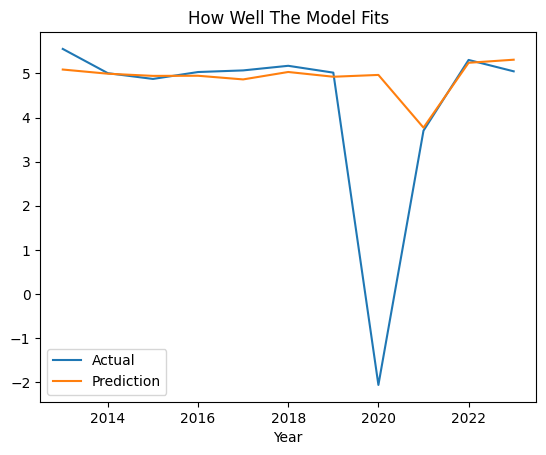

In [28]:
years = list(range(2013, 2013 + len(y_test)))

# Add 'Year' to your comparison dictionary
compare = {
    "Year": years,
    "Actual": y_test,
    "Prediction": y_pred
}

# Create the DataFrame
compare_df = pd.DataFrame(compare)

# Optional: Set 'Year' as the index for better readability
compare_df.set_index("Year", inplace=True)
print(compare_df)
compare_df.plot(title='How Well The Model Fits')

In [57]:
# feature importace

lasso_model = full_pipeline_lag1_lasso.named_steps['model']

coef = {"Trainning Label" : ['gdp_growth_lag1(%)', 'gdp_growth_lag2(%)',
       'household_consumption(%)_lag1', 'fdi_net_flows(US$)_lag1',
       'gross_capital_formation_growth(%)_lag1',
       'export-import_ratio',
       'exchange_rate(IDR/US$)_lag1'],

        "Coefficient" : lasso_model.coef_
}

In [58]:
print(len(coef['Trainning Label']))
print(len(coef['Coefficient']))

7
7


<Axes: >

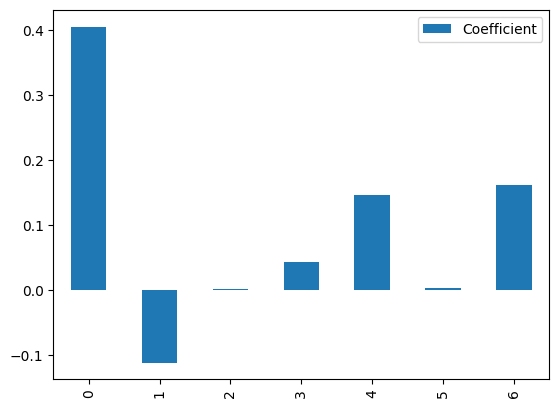

In [ ]:

pd.DataFrame(coef).plot(kind='bar')

In [30]:
import pickle

with open('gdp_lasso_model.pkl', 'wb') as f:
    model = pickle.dump( full_pipeline_lag1_lasso, f)